In [8]:
import polars as pl
from astropy.io import fits
import matplotlib.pyplot as plt
import io
import lsdb
import numpy as np
import pyvo as vo
import pandas as pd
#from astropy.coordinates import SkyCoord
import astropy.units as u
import urllib.request
import urllib.parse
from astroquery.simbad import Simbad
from astropy import units as u
from astropy.coordinates import SkyCoord

df = pl.read_parquet('data/ftransfer_lsst_2026-04-01_19851/*')
print(df)
print(df.columns)


shape: (7, 29)
┌──────────────┬──────────────┬──────────────┬──────────────┬───┬──────┬───────┬─────┬─────────────┐
│ diaSourceId  ┆ observation_ ┆ target_name  ┆ diaSource    ┆ … ┆ year ┆ month ┆ day ┆ tns_type_re │
│ ---          ┆ reason       ┆ ---          ┆ ---          ┆   ┆ ---  ┆ ---   ┆ --- ┆ computed    │
│ i64          ┆ ---          ┆ str          ┆ struct[98]   ┆   ┆ i32  ┆ i32   ┆ i32 ┆ ---         │
│              ┆ str          ┆              ┆              ┆   ┆      ┆       ┆     ┆ str         │
╞══════════════╪══════════════╪══════════════╪══════════════╪═══╪══════╪═══════╪═════╪═════════════╡
│ 170032891364 ┆ alert_edfs_b ┆ ddf_edfs_b,  ┆ {17003289136 ┆ … ┆ 2026 ┆ 2     ┆ 20  ┆ Unknown     │
│ 376622       ┆              ┆ lowdust      ┆ 4376622,2026 ┆   ┆      ┆       ┆     ┆             │
│              ┆              ┆              ┆ 021900…      ┆   ┆      ┆       ┆     ┆             │
│ 170032891405 ┆ alert_edfs_b ┆ ddf_edfs_b,  ┆ {17003289140 ┆ … ┆ 2026 ┆ 2  

In [30]:
print(df['prvDiaForcedSources'])

shape: (7,)
Series: 'prvDiaForcedSources' [list[struct[14]]]
[
	[{170028486493208690,170028485670076519,61.54725,-48.119777,2026021800062,100,-6090.235352,557.514282,61090.054409,270707.65625,547.892822,"i",61090.056712,null}, {170028486640009349,170028485670076519,61.547247,-48.119778,2026021800063,124,-7182.805176,581.105713,61090.05484,270318.5625,569.730713,"i",61090.056952,null}, … {170032891364376899,170028485670076519,61.547253,-48.119784,2026021900113,61,-64.016846,461.000702,61091.10448,215911.390625,444.868042,"r",61091.106302,null}]
	[{170019696458334251,313871013803196542,63.202568,-47.272113,2026021600107,135,3648.343506,331.201752,61088.098476,122751.914062,318.428925,"r",61088.100411,null}, {170028485707300909,313871013803196542,63.202568,-47.272113,2026021800056,137,-1500.896973,433.583862,61090.047584,152016.171875,426.848114,"i",61090.049378,null}, … {170032891405271142,313871013803196542,63.202667,-47.272107,2026021900113,139,7008.754883,374.187408,61091.10448,134404

In [32]:
print(df['diaObject'][0])
# diaObjId = '170028485670076519' 

{'diaObjectId': 170028485670076519, 'validityStartMjdTai': 61091.10630213425, 'ra': 61.547253350901634, 'raErr': 3.09212111915258e-07, 'dec': -48.11978375425382, 'decErr': 3.0619406743426225e-07, 'ra_dec_Cov': -4.3624359364589926e-16, 'u_psfFluxMean': None, 'u_psfFluxMeanErr': None, 'u_psfFluxSigma': None, 'u_psfFluxNdata': 0, 'u_fpFluxMean': None, 'u_fpFluxMeanErr': None, 'g_psfFluxMean': None, 'g_psfFluxMeanErr': None, 'g_psfFluxSigma': None, 'g_psfFluxNdata': 0, 'g_fpFluxMean': None, 'g_fpFluxMeanErr': None, 'r_psfFluxMean': -419.5357666015625, 'r_psfFluxMeanErr': 111.80501556396484, 'r_psfFluxSigma': 2458.09619140625, 'r_psfFluxNdata': 16, 'r_fpFluxMean': None, 'r_fpFluxMeanErr': None, 'i_psfFluxMean': None, 'i_psfFluxMeanErr': None, 'i_psfFluxSigma': None, 'i_psfFluxNdata': 0, 'i_fpFluxMean': None, 'i_fpFluxMeanErr': None, 'z_psfFluxMean': None, 'z_psfFluxMeanErr': None, 'z_psfFluxSigma': None, 'z_psfFluxNdata': 0, 'z_fpFluxMean': None, 'z_fpFluxMeanErr': None, 'y_psfFluxMean': No

In [38]:
q = pd.read_csv('/Users/vasqum2/lsst-hackathon/rubin-mms-hackathon/data/313985344757301296.csv')
q['r:scienceFlux']

0      46172.113
1      41259.930
         ...    
183    35619.605
184    25465.033
Name: r:scienceFlux, Length: 185, dtype: float64

In [40]:
# settling filter + AB zeropoint

filters = ['u', 'g', 'r', 'i', 'z', 'y']
ABzeropoint = {'u': [26.52], 'g': [28.51], 'r': [28.36], 'i': [28.17], 'z': [27.78], 'y': [26.82]}

# these need to be determined, talk w Jessie abt it
sdss_mag_lim = {'u': [18], 'g': [18], 'r': [18], 'i': [18], 'z': [18], 'y': [18]}

for filt in filters:
    ABflux = float(3631*10**(-0.4*ABzeropoint[filt][0]))
    ABzeropoint[filt].append(ABflux)

In [43]:
science_mag = {}
science_flux = {}
time_processed_mjd = {}
i = 0
    
for filt in filters:
    science_mag[filt] = []
    science_flux[filt] = []
    time_processed_mjd[filt] = []

while i < len(q):
    filt = q['r:band'][i]
    flux_now = float(q['r:scienceFlux'][i])
    mag_now = float(-2.5*np.log(flux_now) + 31.4)
    
    science_mag[filt].append(mag_now)
    science_flux[filt].append(flux_now)
    time_processed_mjd[filt].append(float(q['r:timeProcessedMjdTai'][i]))
    i += 1

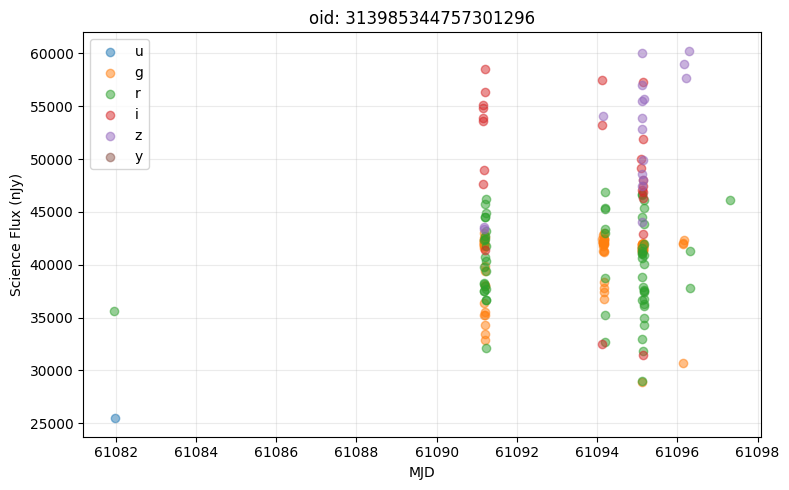

In [51]:
fig, ax = plt.subplots(figsize=(8,5))

for filt in filters:
    # ax.scatter(time_processed_mjd[filt], science_mag[filt], label=filt, alpha=0.5)
    ax.scatter(time_processed_mjd[filt], science_flux[filt], label=filt, alpha=0.5)
# ax.set_ylim((12.5, 1.5))
plt.grid(alpha=0.25)
plt.xlabel('MJD')
plt.ylabel('Science Flux (nJy)')
plt.title('oid: 313985344757301296')
plt.legend(loc='upper left')
plt.tight_layout()